In [5]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os, urllib.request

In [6]:
import os

if not os.path.exists('turkce_isim_clean.txt'):
    print("Dosya bulunamadı.")
else:
    words = open(
        'turkce_isim_clean.txt',
        'r',
        encoding='utf-8'
    ).read().splitlines()

    print('toplam isim:', len(words))

toplam isim: 13865


In [7]:
chars = sorted(list(set(''.join(words))))
stoi = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)
print('vocab boyutu:', vocab_size)

vocab boyutu: 30


In [8]:
# TASK 6 — Türkçe isim dataseti
# WaveNet için context / block_size = 8
block_size = 8

def build_dataset(words_subset, block_size_local=block_size):
    X, Y = [], []

    for w in words_subset:
        context = [0] * block_size_local

        for ch in w + '.':
            ix = stoi[ch]

            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix]

    X = torch.tensor(X)   # (N, block_size_local)
    Y = torch.tensor(Y)   # (N,)

    return X, Y


# Hafta 4 ile aynı split mantığı: %80 / %10 / %10
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1],  block_size_local=8)
Xdev, Ydev = build_dataset(words[n1:n2], block_size_local=8)
Xte,  Yte  = build_dataset(words[n2:],   block_size_local=8)

print('vocab_size:', vocab_size)
print('block_size:', block_size)
print('Xtr :', Xtr.shape)
print('Xdev:', Xdev.shape)
print('Xte :', Xte.shape)


vocab_size: 30
block_size: 8
Xtr : torch.Size([79430, 8])
Xdev: torch.Size([10320, 8])
Xte : torch.Size([10123, 8])


In [9]:
class Embedding:
    # Eski mantık: emb = C[X]

    def __init__(self, num_embeddings, embedding_dim):
        # (vocab_size, emb_dim)
        self.weight = torch.randn((num_embeddings, embedding_dim))

    def __call__(self, IX):
        # Örn. IX: (B, 8)
        # Çıktı: (B, 8, emb_dim)
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]


In [10]:
class Flatten:
    def __init__(self):
        pass

    def __call__(self, x):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []


In [11]:
class FlattenConsecutive:
    # (B, T, C) -> (B, T/n, C*n)

    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape

        # Örn:
        # (B, 8, 10) -> (B, 4, 20)
        # (B, 4, 100) -> (B, 2, 200)
        self.out = x.view(B, T // self.n, C * self.n)

        # Son aşamada T=1 kalırsa:
        # (B, 1, 200) -> (B, 200)
        if self.out.shape[1] == 1:
            self.out = self.out.squeeze(1)

        return self.out

    def parameters(self):
        return []


In [12]:
class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight

        if self.bias is not None:
            self.out += self.bias

        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])


In [13]:
class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # gradient descent ile öğrenilen parametreler
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # gradient descent ile değil, momentum ile güncellenen istatistikler
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):

        if self.training:

            # 2D input: (B, C)
            if x.ndim == 2:
                dim = 0

            # 3D input: (B, T, C)
            elif x.ndim == 3:
                dim = (0, 1)

            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True)

        else:
            xmean = self.running_mean
            xvar = self.running_var

        # normalize
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)

        # öğrenilebilir scale + shift
        self.out = self.gamma * xhat + self.beta

        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    (1 - self.momentum) * self.running_mean
                    + self.momentum * xmean.squeeze()
                )

                self.running_var = (
                    (1 - self.momentum) * self.running_var
                    + self.momentum * xvar.squeeze()
                )

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [14]:
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []


In [15]:
class Sequential:

    def __init__(self, layers):
        self.layers = layers                    # katman listesi, sırası = forward sırası

    def __call__(self, x):
        for layer in self.layers:               # her katmanın çıktısı bir sonrakinin girdisi
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        # tüm katmanların parametrelerini tek düz listede topla
        return [p for layer in self.layers for p in layer.parameters()]


vocab_size      : 30
block_size      : 8
embedding dim   : 10
hidden width    : 100
parametre sayısı: 45930

Shape akışı
input: (4, 8)
Embedding           : (4, 8, 10)
FlattenConsecutive  : (4, 4, 20)
Linear              : (4, 4, 100)
BatchNorm1d         : (4, 4, 100)
Tanh                : (4, 4, 100)
FlattenConsecutive  : (4, 2, 200)
Linear              : (4, 2, 100)
BatchNorm1d         : (4, 2, 100)
Tanh                : (4, 2, 100)
FlattenConsecutive  : (4, 200)
Linear              : (4, 100)
BatchNorm1d         : (4, 100)
Tanh                : (4, 100)
Linear              : (4, 30)
      0/  40000: 3.4015
  10000/  40000: 2.0849
  20000/  40000: 1.8621
  30000/  40000: 2.3858


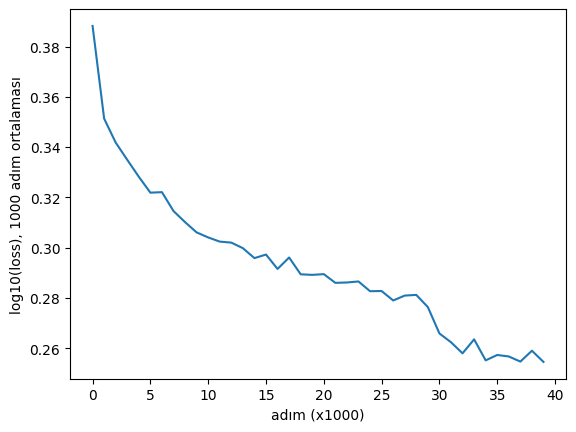

WaveNet train loss: 1.7838389873504639
WaveNet dev loss  : 2.2716825008392334
cantürk.
efeki.
ertop.
akaygun.
gülsan.
kerkaya.
gaziyee.
sever.
hürhalit.
sertan.
efdan.
birakan.
aslıbe.
çiken.
nurfaip.
sesel.
bengizar.
nure.
süreş.
alettin.


In [16]:
# TASK 6 — Türkçe WaveNet
#
# Karşılaştırmayı daha temiz tutmak için:
# Hafta 4 Türkçe MLP: block_size=3, emb_dim=10, n_hidden=100
# Hafta 6 Türkçe WaveNet: block_size=8, emb_dim=10, n_hidden=100
#
# Böylece embedding ve hidden width aynı kalıyor.
# Değişen ana şeyler: context 3 -> 8 ve düz MLP -> hiyerarşik WaveNet.

torch.manual_seed(2147483647)

block_size = 8
emb_dim = 10
n_hidden = 100

model = Sequential([
    # (B, 8) -> (B, 8, 10)
    Embedding(vocab_size, emb_dim),

    # 8 -> 4
    # (B, 8, 10) -> (B, 4, 20) -> (B, 4, 100)
    FlattenConsecutive(2),
    Linear(emb_dim * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),

    # 4 -> 2
    # (B, 4, 100) -> (B, 2, 200) -> (B, 2, 100)
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),

    # 2 -> 1
    # (B, 2, 100) -> (B, 200) -> (B, 100)
    FlattenConsecutive(2),
    Linear(n_hidden * 2, n_hidden, bias=False),
    BatchNorm1d(n_hidden),
    Tanh(),

    # Türkçe vocab için final logits
    # (B, 100) -> (B, vocab_size)
    Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.01

parameters = model.parameters()

print('vocab_size      :', vocab_size)
print('block_size      :', block_size)
print('embedding dim   :', emb_dim)
print('hidden width    :', n_hidden)
print('parametre sayısı:', sum(p.nelement() for p in parameters))

for p in parameters:
    p.requires_grad = True


# ------------------------------------------------------------
# SHAPE KONTROLÜ

ix = torch.randint(0, Xtr.shape[0], (4,))
Xb, Yb = Xtr[ix], Ytr[ix]

logits = model(Xb)

print('\nShape akışı')
print('input:', tuple(Xb.shape))

for layer in model.layers:
    print(f'{layer.__class__.__name__:<20}: {tuple(layer.out.shape)}')


# ------------------------------------------------------------
# EĞİTİM

max_steps = 40000
batch_size = 32
lossi = []

for i in range(max_steps):

    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in parameters:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < int(0.75 * max_steps) else 0.01

    for p in parameters:
        p.data += -lr * p.grad

    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    lossi.append(loss.log10().item())


# ------------------------------------------------------------
# LOSS EĞRİSİ

lossi_t = torch.tensor(lossi)
lossi_avg = lossi_t.view(-1, 1000).mean(1)

plt.plot(lossi_avg)
plt.xlabel('adım (x1000)')
plt.ylabel('log10(loss), 1000 adım ortalaması')
plt.show()


# ------------------------------------------------------------
# EVALUATION

for layer in model.layers:
    layer.training = False


@torch.no_grad()
def split_loss_wave(split):

    x, y = {
        'train': (Xtr, Ytr),
        'val':   (Xdev, Ydev),
        'test':  (Xte, Yte),
    }[split]

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    return loss.item()


wave_train_loss = split_loss_wave('train')
wave_dev_loss = split_loss_wave('val')

print('WaveNet train loss:', wave_train_loss)
print('WaveNet dev loss  :', wave_dev_loss)


# ------------------------------------------------------------
# TÜRKÇE İSİM ÖRNEKLEME

g = torch.Generator().manual_seed(2147483647 + 10)

generated_names = []

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:

        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g
        ).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    name = ''.join(itos[i] for i in out)
    generated_names.append(name)
    print(name)


In [17]:
# TASK 6 — Hafta 4 Türkçe MLP baseline ile karşılaştırma
#
# Aynı Türkçe kelime listesi ve aynı %80/%10/%10 split kullanılıyor.
# MLP: context=3, emb_dim=10, hidden=100
# WaveNet: context=8, emb_dim=10, hidden=100

def build_dataset_for_block(words_subset, block_size_local):
    X, Y = [], []

    for w in words_subset:
        context = [0] * block_size_local

        for ch in w + '.':
            ix = stoi[ch]

            X.append(context)
            Y.append(ix)

            context = context[1:] + [ix]

    return torch.tensor(X), torch.tensor(Y)


# ------------------------------------------------------------
# HAFTA 4 TÜRKÇE MLP BASELINE — context = 3

Xtr3, Ytr3 = build_dataset_for_block(words[:n1], 3)
Xdev3, Ydev3 = build_dataset_for_block(words[n1:n2], 3)

torch.manual_seed(2147483647)

mlp_model = Sequential([
    Embedding(vocab_size, 10),
    Flatten(),
    Linear(3 * 10, 100, bias=False),
    BatchNorm1d(100),
    Tanh(),
    Linear(100, vocab_size),
])

with torch.no_grad():
    mlp_model.layers[-1].weight *= 0.01

mlp_params = mlp_model.parameters()

for p in mlp_params:
    p.requires_grad = True

for layer in mlp_model.layers:
    layer.training = True

max_steps = 40000
batch_size = 32

for i in range(max_steps):

    ix = torch.randint(0, Xtr3.shape[0], (batch_size,))
    Xb, Yb = Xtr3[ix], Ytr3[ix]

    logits = mlp_model(Xb)
    loss = F.cross_entropy(logits, Yb)

    for p in mlp_params:
        p.grad = None

    loss.backward()

    lr = 0.1 if i < int(0.75 * max_steps) else 0.01

    for p in mlp_params:
        p.data += -lr * p.grad


for layer in mlp_model.layers:
    layer.training = False


with torch.no_grad():
    mlp_dev_loss = F.cross_entropy(
        mlp_model(Xdev3),
        Ydev3
    ).item()


# ------------------------------------------------------------
# SON KARŞILAŞTIRMA

print('\nTASK 6 KARŞILAŞTIRMA')
print('-' * 62)

print(
    f"{'Model':<28} {'Context':>8} {'Emb dim':>9} {'Hidden':>8} {'Dev loss':>10}"
)

print(
    f"{'Hafta 4 Türkçe MLP':<28} "
    f"{3:>8} "
    f"{10:>9} "
    f"{100:>8} "
    f"{mlp_dev_loss:>10.4f}"
)

print(
    f"{'Hafta 6 Türkçe WaveNet':<28} "
    f"{8:>8} "
    f"{10:>9} "
    f"{100:>8} "
    f"{wave_dev_loss:>10.4f}"
)

print('-' * 62)

improvement = mlp_dev_loss - wave_dev_loss

print('Dev loss farkı (MLP - WaveNet):', round(improvement, 4))

if improvement > 0:
    print(
        'WaveNet daha düşük dev loss verdi. '
        'Daha uzun context ve hiyerarşik birleştirme validation performansını iyileştirdi.'
    )
else:
    print(
        'Bu koşuda WaveNet daha düşük dev loss vermedi. '
        'Daha uzun context tek başına garanti bir iyileşme sağlamadı.'
    )


print('\nTask 6 için örnek Türkçe isimler:')
for name in generated_names[:10]:
    print(name)



TASK 6 KARŞILAŞTIRMA
--------------------------------------------------------------
Model                         Context   Emb dim   Hidden   Dev loss
Hafta 4 Türkçe MLP                  3        10      100     2.3815
Hafta 6 Türkçe WaveNet              8        10      100     2.2717
--------------------------------------------------------------
Dev loss farkı (MLP - WaveNet): 0.1098
WaveNet daha düşük dev loss verdi. Daha uzun context ve hiyerarşik birleştirme validation performansını iyileştirdi.

Task 6 için örnek Türkçe isimler:
cantürk.
efeki.
ertop.
akaygun.
gülsan.
kerkaya.
gaziyee.
sever.
hürhalit.
sertan.
